In [ ]:
!pip install sweetviz
!pip install dataprofiler

In [ ]:
!pip install ydata_profiling
!pip install pandera
!pip install cerberus

In [60]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
from ydata_profiling import ProfileReport
import pandera as pa
from pandera import Column, DataFrameSchema, Check
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [61]:
df_raw = pd.read_csv('retail_data.csv')
df_raw.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [62]:
df_raw.shape

(302010, 30)

In [63]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

In [64]:
print(df_raw.dtypes)
print()

Transaction_ID      float64
Customer_ID         float64
Name                 object
Email                object
Phone               float64
Address              object
City                 object
State                object
Zipcode             float64
Country              object
Age                 float64
Gender               object
Income               object
Customer_Segment     object
Date                 object
Year                float64
Month                object
Time                 object
Total_Purchases     float64
Amount              float64
Total_Amount        float64
Product_Category     object
Product_Brand        object
Product_Type         object
Feedback             object
Shipping_Method      object
Payment_Method       object
Order_Status         object
Ratings             float64
products             object
dtype: object



In [65]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                  Missing Count  Missing %
Transaction_ID              333      0.110
Customer_ID                 308      0.102
Name                        382      0.126
Email                       347      0.115
Phone                       362      0.120
Address                     315      0.104
City                        248      0.082
State                       281      0.093
Zipcode                     340      0.113
Country                     271      0.090
Age                         173      0.057
Gender                      317      0.105
Income                      290      0.096
Customer_Segment            215      0.071
Date                        359      0.119
Year                        350      0.116
Month                       273      0.090
Time                        350      0.116
Total_Purchases             361      0.120
Amount                      357      0.118
Total_Amount                350      0.116
Product_Category            283      0.094
Product_Bra

In [66]:
total_cells = np.prod(df_raw.shape)
total_missing = missing.sum()
print(f'\nPercent of data that is missing: {(total_missing/total_cells)*100:.3f}%')
print(f'Duplicate rows: {df_raw.duplicated().sum()}')


Percent of data that is missing: 0.093%
Duplicate rows: 4


In [67]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df_raw,
    title='Retail Transactional Dataset â€” Profiling Report (Phase 1)',
    explorative=True,
    minimal=False
)

profile.to_file('profiling_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 30/30 [01:15<00:00,  2.52s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [68]:
df = df_raw.copy()
print(f'Starting shape: {df.shape}')

Starting shape: (302010, 30)


In [69]:
before = len(df)
print('Duplicate rows found:')
print(df[df.duplicated()])

Duplicate rows found:
        Transaction_ID  Customer_ID             Name                  Email  \
299759       4476510.0      20103.0    Christine Kim      James11@gmail.com   
301094       5340129.0      29920.0     Collin Davis   Courtney47@gmail.com   
301362       4942326.0      25416.0    Pamela Martin  Christine83@gmail.com   
301486       3200766.0      49598.0  Mikayla Mueller    Kenneth43@gmail.com   

               Phone                       Address        City  \
299759  2.383778e+09   8176 Randy Squares Apt. 772   Kitchener   
301094  4.087767e+09  371 Cynthia Drives Suite 699  Wollongong   
301362  6.657934e+09             9851 Myers Tunnel   Leicester   
301486  6.980439e+09    716 Joshua Rapids Apt. 790      Bremen   

                  State  Zipcode    Country  ...  Total_Amount  \
299759          Ontario   7099.0     Canada  ...    940.619277   
301094  New South Wales  47758.0  Australia  ...   2201.568075   
301362          England  57655.0         UK  ...   15

In [70]:
df.drop_duplicates(inplace=True)

after = len(df)
print(f'\nRemoved {before - after} duplicate row(s). Rows remaining: {after:,}')


Removed 4 duplicate row(s). Rows remaining: 302,006


In [71]:
df_raw.dtypes

,0
Transaction_ID,float64
Customer_ID,float64
Name,object
Email,object
Phone,float64
Address,object
City,object
State,object
Zipcode,float64
Country,object


In [72]:
df['Transaction_ID'] = df['Transaction_ID'].dropna().apply(lambda x: str(int(x)))
df['Customer_ID']    = df['Customer_ID'].dropna().apply(lambda x: str(int(x)))

df['Phone'] = df['Phone'].dropna().apply(lambda x: str(int(x)))

df['Zipcode'] = df['Zipcode'].dropna().apply(lambda x: str(int(x)))

df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

df['Ratings'] = pd.to_numeric(df['Ratings'], errors='coerce').astype('Int64')

print('Data types fixed:')
print(df[['Transaction_ID','Customer_ID','Phone','Zipcode','Year','Ratings']].dtypes)

Data types fixed:
Transaction_ID    object
Customer_ID       object
Phone             object
Zipcode           object
Year               Int64
Ratings            Int64
dtype: object


In [73]:
sample_slash = df_raw['Date'].dropna()[df_raw['Date'].dropna().str.contains('/')].head(3).tolist()
sample_dash  = df_raw['Date'].dropna()[df_raw['Date'].dropna().str.contains('-')].head(3).tolist()
print('Format 1 (M/D/YYYY):', sample_slash)
print('Format 2 (MM-DD-YY):', sample_dash)

Format 1 (M/D/YYYY): ['9/18/2023', '12/31/2023', '4/26/2023']
Format 2 (MM-DD-YY): ['05-08-23', '01-10-24', '01-06-24']


In [74]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

print("Date column after conversion:")
print(df['Date'].head())

nat_count = df['Date'].isna().sum()
print(f"\nNaT (unparseable) dates: {nat_count}")

Date column after conversion:
0   2023-09-18
1   2023-12-31
2   2023-04-26
3          NaT
4          NaT
Name: Date, dtype: datetime64[ns]

NaT (unparseable) dates: 119113


In [75]:
before = len(df)
df.dropna(subset=['Transaction_ID', 'Customer_ID', 'Name'], how='all', inplace=True)
print(f'Rows dropped (all identity fields null): {before - len(df)}')

num_cols = ['Age', 'Amount', 'Total_Amount', 'Total_Purchases', 'Ratings']
for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  {col}: filled NaN with median = {median_val:.2f}')

df['Year']  = df['Year'].fillna(df['Date'].dt.year)
df['Year'].fillna(df['Year'].mode()[0], inplace=True)
df['Month'] = df['Month'].fillna(df['Date'].dt.strftime('%B'))

Rows dropped (all identity fields null): 0
  Age: filled NaN with median = 32.00
  Amount: filled NaN with median = 255.47
  Total_Amount: filled NaN with median = 1041.10
  Total_Purchases: filled NaN with median = 5.00
  Ratings: filled NaN with median = 3.00


In [76]:
cat_cols = ['Gender', 'Income', 'Customer_Segment', 'Product_Category',
            'Product_Brand', 'Feedback', 'Shipping_Method', 'Payment_Method',
            'Order_Status', 'Country']
for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  {col}: filled NaN with mode = "{mode_val}"')

for col in ['Email', 'Phone', 'Address', 'City', 'State', 'Zipcode', 'Time']:
    df[col].fillna('Unknown', inplace=True)

before = len(df)
df.dropna(subset=['Date'], inplace=True)
print(f'\nRows dropped (unparseable date): {before - len(df)}')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')
print(f'Final shape after handling missing values: {df.shape}')

  Gender: filled NaN with mode = "Male"
  Income: filled NaN with mode = "Medium"
  Customer_Segment: filled NaN with mode = "Regular"
  Product_Category: filled NaN with mode = "Electronics"
  Product_Brand: filled NaN with mode = "Pepsi"
  Feedback: filled NaN with mode = "Excellent"
  Shipping_Method: filled NaN with mode = "Same-Day"
  Payment_Method: filled NaN with mode = "Credit Card"
  Order_Status: filled NaN with mode = "Delivered"
  Country: filled NaN with mode = "USA"

Rows dropped (unparseable date): 119113

Remaining missing values: 665
Final shape after handling missing values: (182893, 30)


Total_Amount â€” Q1: 440.34, Q3: 2024.47, IQR: 1584.14
Acceptable range: [-1935.87, 4400.68]
Outliers found: 2467


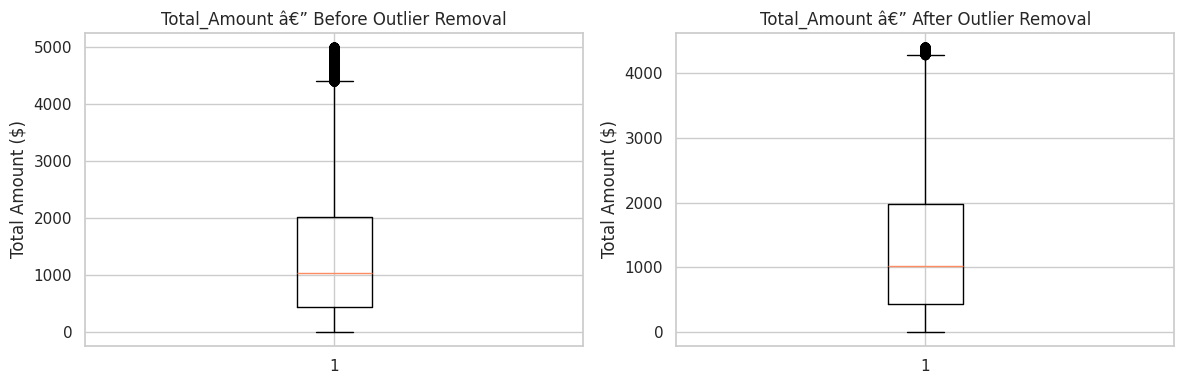

Removed 2467 outlier rows.
Shape after outlier removal: (180426, 30)


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Total_Amount'].dropna())
axes[0].set_title('Total_Amount â€” Before Outlier Removal')
axes[0].set_ylabel('Total Amount ($)')

before = len(df)
col = 'Total_Amount'
Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Total_Amount â€” Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}')
print(f'Acceptable range: [{lower_bound:.2f}, {upper_bound:.2f}]')
print(f'Outliers found: {((df[col] < lower_bound) | (df[col] > upper_bound)).sum()}')

df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

axes[1].boxplot(df['Total_Amount'].dropna())
axes[1].set_title('Total_Amount â€” After Outlier Removal')
axes[1].set_ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

print(f'Removed {before - len(df)} outlier rows.')
print(f'Shape after outlier removal: {df.shape}')

In [78]:
df.to_csv('retail_data_cleaned.csv', index=False)

In [79]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

schema = pa.DataFrameSchema(
    {
        'Transaction_ID'   : Column(str,  nullable=False),
        'Customer_ID'      : Column(str,  nullable=False),
        'Name'             : Column(str,  nullable=True),

        'Email'            : Column(str,  Check(lambda s: s.str.contains('@').all()), nullable=True),
        'Phone'            : Column(str,  nullable=True),

        'Address'          : Column(str,  nullable=True),
        'City'             : Column(str,  nullable=True),
        'State'            : Column(str,  nullable=True),
        'Zipcode'          : Column(str,  nullable=True),
        'Country'          : Column(str,  Check.isin(['Germany','UK','Australia','Canada','USA','Unknown']), nullable=True),

        'Age'              : Column(float, Check.in_range(18, 70),  nullable=False),
        'Gender'           : Column(str,   Check.isin(['Male','Female']), nullable=True),
        'Income'           : Column(str,   Check.isin(['Low','Medium','High']), nullable=True),
        'Customer_Segment' : Column(str,   Check.isin(['Regular','Premium','New']), nullable=True),

        'Year'             : Column('Int64', Check.in_range(2020, 2025), nullable=True),
        'Month'            : Column(str,  nullable=True),
        'Time'             : Column(str,  nullable=True),

        'Total_Purchases'  : Column(float, Check.in_range(1, 10),   nullable=False),
        'Amount'           : Column(float, Check.in_range(10, 500), nullable=False),
        'Total_Amount'     : Column(float, Check.greater_than(0),   nullable=False),

        'Product_Category' : Column(str,  Check.isin(['Clothing','Electronics','Books','Home Decor','Grocery']), nullable=True),
        'Product_Brand'    : Column(str,  nullable=True),
        'Product_Type'     : Column(str,  nullable=True),
        'products'         : Column(str,  nullable=True),

        'Feedback'         : Column(str,  Check.isin(['Excellent','Good','Average','Bad']), nullable=True),
        'Shipping_Method'  : Column(str,  Check.isin(['Same-Day','Standard','Express']), nullable=True),
        'Payment_Method'   : Column(str,  Check.isin(['Debit Card','Credit Card','PayPal','Cash']), nullable=True),
        'Order_Status'     : Column(str,  Check.isin(['Shipped','Processing','Pending','Delivered']), nullable=True),
        'Ratings'          : Column('Int64', Check.in_range(1, 5), nullable=False),
    },
    coerce=True
)

In [80]:
try:
    validated_df = schema.validate(df, lazy=True)
    print('Validation PASSED â€” all schema checks satisfied.')
    print(f'Validated rows: {validated_df.shape[0]:,}')
except pa.errors.SchemaErrors as exc:
    failure_cases = exc.failure_cases
    print(f'Validation completed with {len(failure_cases)} failure case(s):')
    print(failure_cases[['schema_context','column','check','failure_case','index']].head(20))

Validation completed with 416 failure case(s):
    schema_context          column         check failure_case   index
0           Column  Transaction_ID  not_nullable          NaN    1609
1           Column  Transaction_ID  not_nullable          NaN    3213
284         Column     Customer_ID  not_nullable          NaN  111842
283         Column     Customer_ID  not_nullable          NaN  109736
282         Column     Customer_ID  not_nullable          NaN  109202
281         Column     Customer_ID  not_nullable          NaN  108508
280         Column     Customer_ID  not_nullable          NaN  104345
279         Column     Customer_ID  not_nullable          NaN  101532
278         Column     Customer_ID  not_nullable          NaN  100761
277         Column     Customer_ID  not_nullable          NaN   99980
276         Column     Customer_ID  not_nullable          NaN   99459
275         Column     Customer_ID  not_nullable          NaN   94739
274         Column     Customer_ID  not_nul

In [81]:
print(f'{"Column":<22} {"Check":<30} {"Result"}')
print('-' * 65)

checks = [
    ('Transaction_ID',   'Not null',             df['Transaction_ID'].notna().all()),
    ('Customer_ID',      'Not null',             df['Customer_ID'].notna().all()),
    ('Email',            'Contains @',           df['Email'].dropna().str.contains('@').all()),
    ('Age',              'Between 18 and 70',    df['Age'].between(18, 70).all()),
    ('Gender',           'Male or Female',       df['Gender'].isin(['Male','Female']).all()),
    ('Income',           'Low/Medium/High',      df['Income'].isin(['Low','Medium','High']).all()),
    ('Customer_Segment', 'Regular/Premium/New',  df['Customer_Segment'].isin(['Regular','Premium','New']).all()),
    ('Ratings',          'Between 1 and 5',      df['Ratings'].between(1, 5).all()),
    ('Amount',           'Between 10 and 500',   df['Amount'].between(10, 500).all()),
    ('Total_Amount',     'Greater than 0',       (df['Total_Amount'] > 0).all()),
    ('Total_Purchases',  'Between 1 and 10',     df['Total_Purchases'].between(1, 10).all()),
    ('Product_Category', 'Valid category',       df['Product_Category'].isin(['Clothing','Electronics','Books','Home Decor','Grocery']).all()),
    ('Order_Status',     'Valid status',         df['Order_Status'].isin(['Shipped','Processing','Pending','Delivered']).all()),
    ('Payment_Method',   'Valid method',         df['Payment_Method'].isin(['Debit Card','Credit Card','PayPal','Cash']).all()),
    ('Shipping_Method',  'Valid method',         df['Shipping_Method'].isin(['Same-Day','Standard','Express']).all()),
    ('Duplicates',       'Zero duplicate rows',  df.duplicated().sum() == 0),
]

all_pass = True
for col, check, result in checks:
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_pass = False
    print(f'{col:<22} {check:<30} {status}')

print('-' * 65)
print('Overall:', 'ALL CHECKS PASSED' if all_pass else 'Some checks failed â€” review above')

Column                 Check                          Result
-----------------------------------------------------------------
Transaction_ID         Not null                       FAIL
Customer_ID            Not null                       FAIL
Email                  Contains @                     FAIL
Age                    Between 18 and 70              PASS
Gender                 Male or Female                 PASS
Income                 Low/Medium/High                PASS
Customer_Segment       Regular/Premium/New            PASS
Ratings                Between 1 and 5                PASS
Amount                 Between 10 and 500             PASS
Total_Amount           Greater than 0                 PASS
Total_Purchases        Between 1 and 10               PASS
Product_Category       Valid category                 PASS
Order_Status           Valid status                   PASS
Payment_Method         Valid method                   PASS
Shipping_Method        Valid method            

In [82]:
sns.set_theme(style='whitegrid', palette='Set2')
TITLE_SIZE = 13
LABEL_SIZE = 10
FIG_BG     = '#f8f9fa'

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

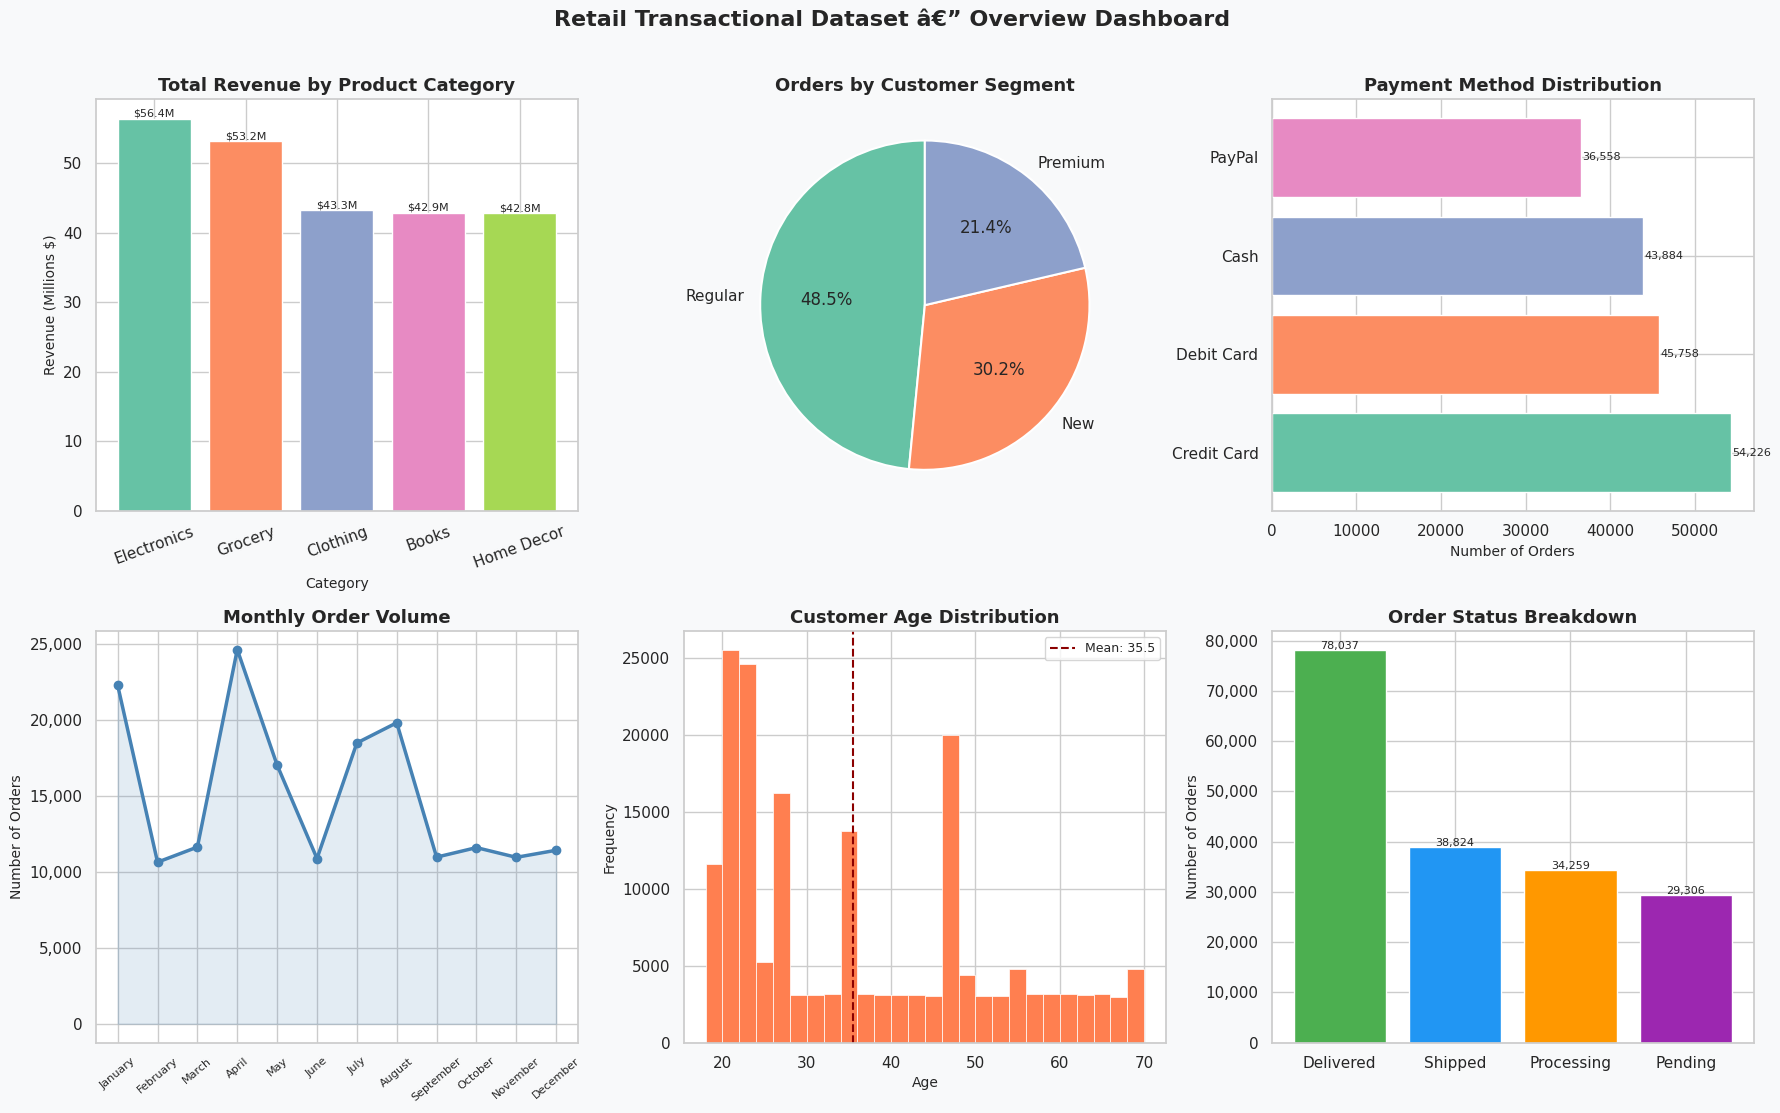

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(FIG_BG)
fig.suptitle('Retail Transactional Dataset â€” Overview Dashboard', fontsize=16, fontweight='bold', y=1.01)

ax = axes[0, 0]
cat_rev = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)
bars = ax.bar(cat_rev.index, cat_rev.values / 1e6, color=sns.color_palette('Set2', len(cat_rev)))
ax.set_title('Total Revenue by Product Category', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlabel('Category', fontsize=LABEL_SIZE)
ax.set_ylabel('Revenue (Millions $)', fontsize=LABEL_SIZE)
ax.tick_params(axis='x', rotation=20)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${bar.get_height():.1f}M', ha='center', fontsize=8)

ax = axes[0, 1]
seg_counts = df['Customer_Segment'].value_counts()
ax.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
       colors=sns.color_palette('Set2', len(seg_counts)), startangle=90,
       wedgeprops={'edgecolor':'white', 'linewidth': 1.5})
ax.set_title('Orders by Customer Segment', fontsize=TITLE_SIZE, fontweight='bold')

ax = axes[0, 2]
pay_counts = df['Payment_Method'].value_counts()
bars = ax.barh(pay_counts.index, pay_counts.values, color=sns.color_palette('Set2', len(pay_counts)))
ax.set_title('Payment Method Distribution', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlabel('Number of Orders', fontsize=LABEL_SIZE)
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=8)

ax = axes[1, 0]
monthly = df.groupby('Month', observed=True).size().reset_index(name='Orders')
ax.plot(monthly['Month'], monthly['Orders'], marker='o', linewidth=2.5,
        color='steelblue', markersize=6)
ax.fill_between(range(len(monthly)), monthly['Orders'], alpha=0.15, color='steelblue')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month'], rotation=40, fontsize=8)
ax.set_title('Monthly Order Volume', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1, 1]
ax.hist(df['Age'], bins=26, color='coral', edgecolor='white', linewidth=0.5)
ax.axvline(df['Age'].mean(), color='darkred', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
ax.set_title('Customer Age Distribution', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlabel('Age', fontsize=LABEL_SIZE)
ax.set_ylabel('Frequency', fontsize=LABEL_SIZE)
ax.legend(fontsize=9)

ax = axes[1, 2]
status_counts = df['Order_Status'].value_counts()
bars = ax.bar(status_counts.index, status_counts.values,
              color=['#4CAF50','#2196F3','#FF9800','#9C27B0'])
ax.set_title('Order Status Breakdown', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('dashboard_fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

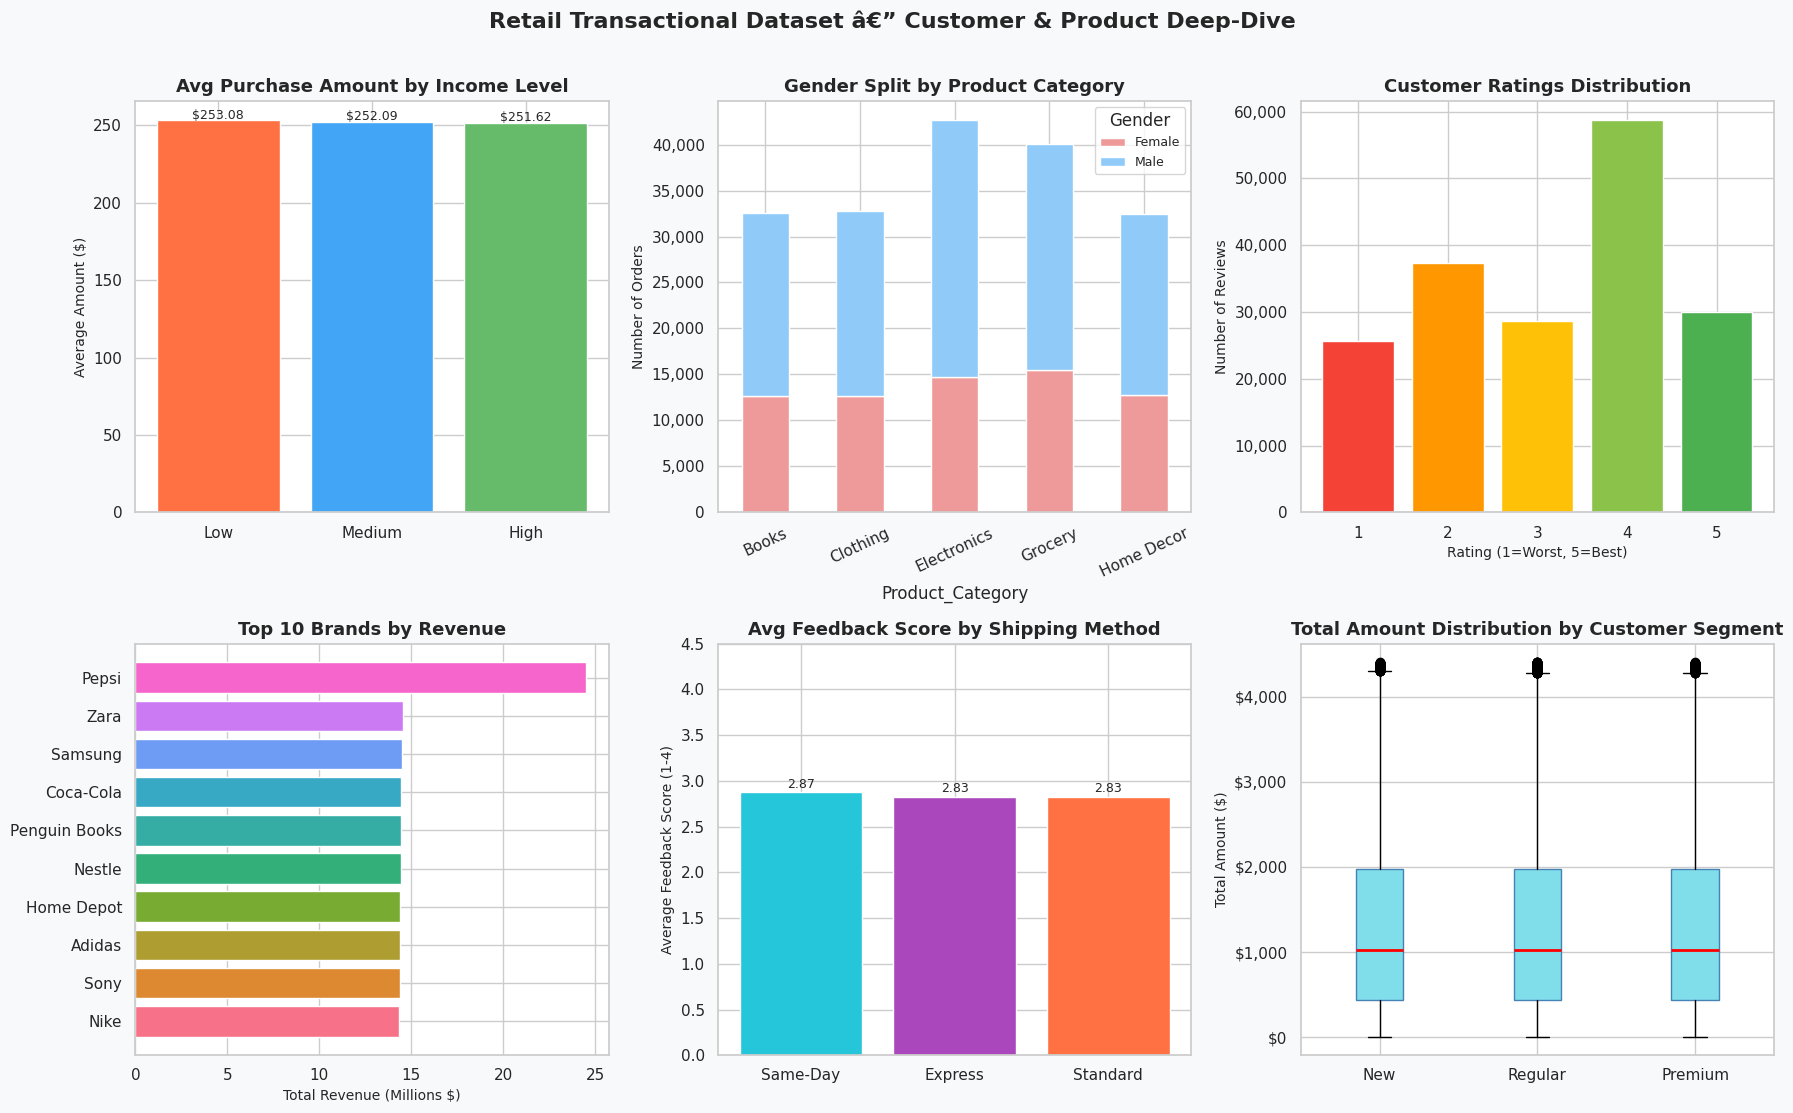

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(FIG_BG)
fig.suptitle('Retail Transactional Dataset â€” Customer & Product Deep-Dive', fontsize=16, fontweight='bold', y=1.01)

ax = axes[0, 0]
income_avg = df.groupby('Income')['Amount'].mean().reindex(['Low','Medium','High'])
bars = ax.bar(income_avg.index, income_avg.values, color=['#FF7043','#42A5F5','#66BB6A'])
ax.set_title('Avg Purchase Amount by Income Level', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Average Amount ($)', fontsize=LABEL_SIZE)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'${bar.get_height():.2f}', ha='center', fontsize=9)

ax = axes[0, 1]
gender_cat = df.groupby(['Product_Category','Gender']).size().unstack(fill_value=0)
gender_cat.plot(kind='bar', ax=ax, stacked=True, color=['#EF9A9A','#90CAF9'], edgecolor='white')
ax.set_title('Gender Split by Product Category', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=LABEL_SIZE)
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Gender', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[0, 2]
ratings_counts = df['Ratings'].value_counts().sort_index()
ax.bar(ratings_counts.index.astype(str), ratings_counts.values,
       color=['#F44336','#FF9800','#FFC107','#8BC34A','#4CAF50'])
ax.set_title('Customer Ratings Distribution', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlabel('Rating (1=Worst, 5=Best)', fontsize=LABEL_SIZE)
ax.set_ylabel('Number of Reviews', fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax = axes[1, 0]
top_brands = df.groupby('Product_Brand')['Total_Amount'].sum().nlargest(10).sort_values()
ax.barh(top_brands.index, top_brands.values / 1e6, color=sns.color_palette('husl', 10))
ax.set_title('Top 10 Brands by Revenue', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_xlabel('Total Revenue (Millions $)', fontsize=LABEL_SIZE)

ax = axes[1, 1]
feedback_map = {'Bad': 1, 'Average': 2, 'Good': 3, 'Excellent': 4}
df['Feedback_Score'] = df['Feedback'].map(feedback_map)
ship_feed = df.groupby('Shipping_Method')['Feedback_Score'].mean().sort_values(ascending=False)
bars = ax.bar(ship_feed.index, ship_feed.values, color=['#26C6DA','#AB47BC','#FF7043'])
ax.set_title('Avg Feedback Score by Shipping Method', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Average Feedback Score (1-4)', fontsize=LABEL_SIZE)
ax.set_ylim(0, 4.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

ax = axes[1, 2]
seg_order = ['New', 'Regular', 'Premium']
data_by_seg = [df[df['Customer_Segment'] == seg]['Total_Amount'].values for seg in seg_order]
bp = ax.boxplot(data_by_seg, labels=seg_order, patch_artist=True,
                boxprops=dict(facecolor='#80DEEA', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
ax.set_title('Total Amount Distribution by Customer Segment', fontsize=TITLE_SIZE, fontweight='bold')
ax.set_ylabel('Total Amount ($)', fontsize=LABEL_SIZE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))

plt.tight_layout()
plt.savefig('dashboard_fig2_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

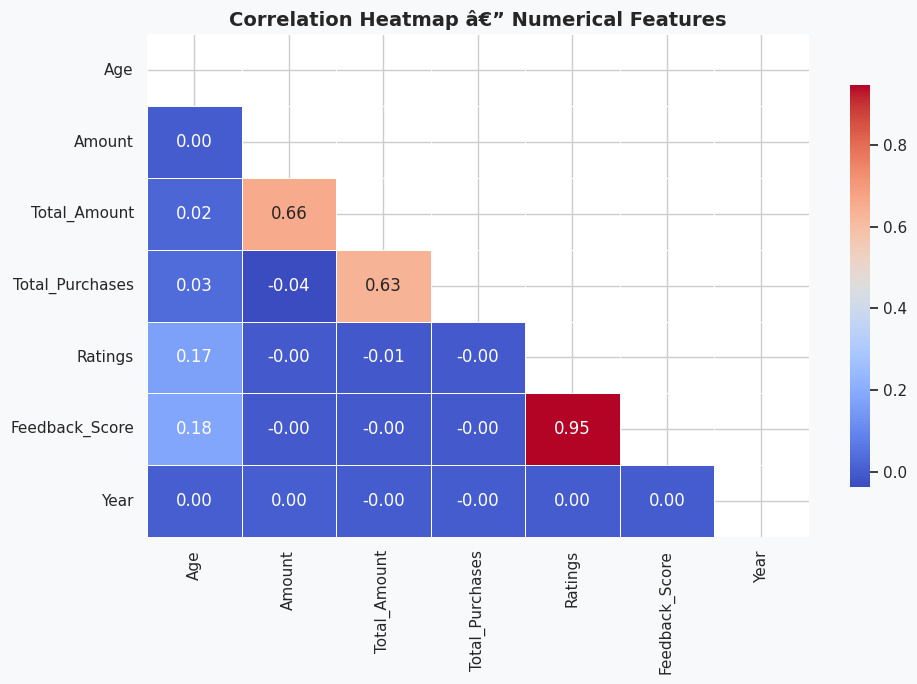

In [85]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(FIG_BG)

num_df = df[['Age','Amount','Total_Amount','Total_Purchases','Ratings','Feedback_Score','Year']]
corr   = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap â€” Numerical Features', fontsize=TITLE_SIZE+1, fontweight='bold')

plt.tight_layout()
plt.savefig('dashboard_fig3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [86]:
print(f'  Total Transactions   : {len(df):,}')
print(f'  Total Revenue        : ${df["Total_Amount"].sum():,.2f}')
print(f'  Average Order Value  : ${df["Amount"].mean():.2f}')
print(f'  Average Rating       : {df["Ratings"].mean():.2f} / 5')
print(f'  Average Customer Age : {df["Age"].mean():.1f} years')
print(f'  Top Product Category : {df["Product_Category"].mode()[0]}')
print(f'  Top Payment Method   : {df["Payment_Method"].mode()[0]}')
print(f'  Top Country          : {df["Country"].mode()[0]}')
print()

  Total Transactions   : 180,426
  Total Revenue        : $238,554,493.77
  Average Order Value  : $252.29
  Average Rating       : 3.17 / 5
  Average Customer Age : 35.5 years
  Top Product Category : Electronics
  Top Payment Method   : Credit Card
  Top Country          : USA



In [87]:
!pip install pycryptodome
!pip install cryptography

In [88]:
import pandas as pd
import numpy as np
import hashlib
import random
import math

df = pd.read_csv('retail_data_cleaned.csv')
print(df.shape)
df.head()

(180426, 30)


,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1414786801,3959 Amanda Burgs,Dortmund,Berlin,77985,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6852899987,82072 Dawn Centers,Nottingham,England,99071,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8362160449,4133 Young Canyon,Geelong,New South Wales,75929,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2,Sports equipment
3,6095326.0,41289.0,Ryan Johnson,Haley12@gmail.com,3292677006,532 Ashley Crest Suite 014,Brisbane,New South Wales,74430,Australia,...,1185.167224,Electronics,Apple,Tablet,Good,Express,PayPal,Pending,4,Lenovo Tab
4,5434096.0,97285.0,Erin Lewis,Arthur76@gmail.com,1578355423,600 Brian Prairie Suite 497,Kitchener,Ontario,47545,Canada,...,630.115295,Electronics,Samsung,Television,Bad,Standard,Cash,Processing,1,QLED TV


In [89]:
def hash_sha256(x):
    return hashlib.sha256(str(x).encode()).hexdigest()

def hash_md5(x):
    return hashlib.md5(str(x).encode()).hexdigest()

df_hashed = df.copy()
df_hashed['Transaction_ID'] = df_hashed['Transaction_ID'].apply(hash_sha256)
df_hashed['Customer_ID'] = df_hashed['Customer_ID'].apply(hash_sha256)
df_hashed['Phone'] = df_hashed['Phone'].apply(hash_sha256)
df_hashed['Email'] = df_hashed['Email'].apply(hash_sha256)
df_hashed['Zipcode'] = df_hashed['Zipcode'].apply(hash_sha256)

df_hashed[['Transaction_ID','Customer_ID','Phone','Email','Zipcode']].head(10)

,Transaction_ID,Customer_ID,Phone,Email,Zipcode
0,f5c87d54c7941dfac74be73f42fbee2a67007d493690eb5fc5522b3ae1c14107,c9008a1893ae907d9fbbd7fc1ad1474b25a3b052d98a8c2ff7b7514764a16613,46f69e3fc920aa5e60232482cc45d6cf898e00ffd43cf387a614c063b71bc713,c8bb01f971c27f47c99adecc9f5e4d69b4a4b8200a5faddc6c3654b205bdffd7,8fa75f0ab018b091848ea67477eeddb27d8e4f539d136c301210ae0ef894a71c
1,dfb02e9a5d19475f5d4b90144f0c8b5bd3db14716b046860af2067eacd4fe41d,35d5b218b23b9649ed1f4d34083e14ef4011bb5c0779652b2a458ecfcc74b09e,eba0db34888286d41eb1525dd6d2c783a4e35a1abef2f11bde003ef4a8a1f0b3,9841f8f8c3b87648a4d3815d28217154b1c8a9ae2b231aef17ec915a36360411,2f16ba42aadb9f23eed5a0da5c501e2a3fa312d4ab4e95d7a8aa3f3c87cff1cb
2,c5cf1530ce3342a116df46269b164981e71a057d7f5d92fcad33be5b9f11485a,f927cc412593ce5f73028ef2c432bad89c7fe92be3c05840e5bf6fea76c17b9a,525061430227200871548c4059f2b4e782483c4eaa6ac26a8b70a71516210e11,2ffdc504caeb0b668c6cdcd946e4c87d6ac62ac608a8a445b94a6c6326afd541,3c4a2af60cc53b9a9103f1e717d4d8bf7b670e7f443ca34c4ce13a64ebbb124d
3,0589bd62be8642a909bb3d107952150963f05ee61ebf24497be9aac9988cebab,672199b236f922af91a366bd10938fb90c74760f635dc165e9dbb7d28af1cc37,1edbbaa79014a299760dc26bf0ec80d7e71ef8112ada7757d8b866c40f5326e9,f921cf5761940dd9e949858242f9ab4cf6ea39daa8e3b7536c055503aa667f69,954bc1a215462d98cbdcdb2c145ab9fe757428bfff5acf6fb4b807dfc9dc087d
4,85ac9df7359b8ed4f676a9c04a1be56f3701378b61e337f86dd2cf8cc7030cb8,13c83ec5497562d9134d825fa718eb2f21ccecabc4f4db8a64ccbdc9a491a01f,f72a73b8fd9f3a98df4b0fc2b3d65e46700fbf2d2b39fa13e73f446c45f7896b,94d2f1421b47847a45a7ce03a3ce6344eed8a84cf31efd368a29c7abb09cdce6,597abee1c369d53a911183eb01b80d0449654dc0f1425b00b3961ce09cd5c2c9
5,2fefa0f81ec16b1bd844af360a8580c4d00b3b78a11b501c195399ae9f55128d,9574f35e2e9f943997c03af92021ea747a8cc57dacb448817c7e1755db910bf1,fdb142a7e33dc3d77f182cdcb1dee87ed4124b52dd27e55661ba9fc4c5790a4a,617585ac408a20979c815bf94eceb68a827325a3e75ddb98599188384542ff8b,365db0cbe54f74422d372ac84d02476eb294e139cf9a7df8dd14926c60de29d3
6,67dd016ecd95a12439b517749d8787cc1494fb01af337e0936b3debc09a4d774,857314b74aadf51f6012596c74287c98b87581588a37b84180410aea2b2c3bfe,0583a57255c54517857ad79420144f507bebf58ce614687c415a0b47e476e701,c2999ef0b3187426949da6df4e17a8e04bcadca87640bf69fcf437425e5bcda2,42c0626ef1bd68bb1abb5bb8ba10e8a7909d3ce31f57215dcb970db94fea3a5d
7,8ca0d5f26414c28bce9663ea2c059ec6bb6cdfb3a76c4275981188ca4af0eef5,22ce98ec2f271a10eeb5856f3d180becdf47c5ea11427edbca399478bca4414d,6529dd8f06269bec98b90aeba60912fbfa766f96f185d1882334eb1747831ca7,ce59ff42b752d588cd4da0799b29a2ef1d4f1a9e545f4d31caa61c8a40a5ab9d,189d4761cccd260f1904c12987be82ed14efc5a1888a71228d2e750321d6dd8c
8,c86520087f415017d09a226315eb3ac80028307eb6bbae666b029b0d810bc641,bc6b4d1dee842f7918780068aa63c94bb7f43e67befe9c0c34fb84d35f15536c,d4d286c3fdc34f8def91c8ab1d56b2fb78af1c2833aef7a1f4bb55183677af48,1e85b1ebb3485ea7e3d768ccab6c2e0eeb95b518a47b3f7015739c29a9c59e9a,c57e45c141c978f153ef39f1b9010a1df634f350c0730d21f0197de4caeda4da
9,d1100ac828a4c0e6833d7458782f54fd80cb512fb505bda23f4f0281f0c07f1e,3a1be64a61ab97aabec4a2f382aaf61ba1959004668b725e736eca7809b69b2c,30fd2972e64a4419377c7a8514c959bf88fd2861894fa1e602d08330b37e1129,d7b5b8a6b64b8cab82a531e61c611a80011b49ec7ea0a6d1918df8895aac2425,14ff3085b7743c634d15e37418ceafcee1cd9ad00c4efb44c54c3a856482caa7


In [90]:
passwords = ['admin123', 'student2026', 'password', 'retail_user', 'qwerty']
print('Password Hashing Demo')
print('-'*70)
for p in passwords:
    h = hashlib.sha256(p.encode()).hexdigest()
    print(p, '->', h)

Password Hashing Demo
----------------------------------------------------------------------
admin123 -> 240be518fabd2724ddb6f04eeb1da5967448d7e831c08c8fa822809f74c720a9
student2026 -> 4f87674c124e626d51eb6a5342debbbdfd0867ada8735d319f89e17d32cb3a4c
password -> 5e884898da28047151d0e56f8dc6292773603d0d6aabbdd62a11ef721d1542d8
retail_user -> 926cb7de9ecfe021b00e140baf50ed2b2d71706c9a32ecd4804881f91294ff32
qwerty -> 65e84be33532fb784c48129675f9eff3a682b27168c0ea744b2cf58ee02337c5


In [91]:
def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.sqrt(n))+1, 2):
        if n % i == 0:
            return False
    return True

def gen_prime(low, high):
    while True:
        x = random.randint(low, high)
        if is_prime(x):
            return x

def gcd(a, b):
    while b != 0:
        a, b = b, a % b
    return a

def ext_gcd(a, b):
    if b == 0:
        return a, 1, 0
    g, x1, y1 = ext_gcd(b, a % b)
    return g, y1, x1 - (a // b) * y1

def mod_inverse(e, phi):
    g, x, y = ext_gcd(e, phi)
    return x % phi

In [92]:
random.seed(7)
p = gen_prime(500, 2000)
q = gen_prime(500, 2000)
while q == p:
    q = gen_prime(500, 2000)

n = p * q
phi = (p - 1) * (q - 1)

e = 65537
if gcd(e, phi) != 1:
    e = 17
    while gcd(e, phi) != 1:
        e += 2

d = mod_inverse(e, phi)

print('p =', p)
print('q =', q)
print('n =', n)
print('phi =', phi)
print('e =', e)
print('d =', d)
print('public key  =', (e, n))
print('private key =', (d, n))

p = 1163
q = 1597
n = 1857311
phi = 1854552
e = 65537
d = 1777865
public key  = (65537, 1857311)
private key = (1777865, 1857311)


In [93]:
def rsa_encrypt(text, e, n):
    cipher = []
    for ch in str(text):
        c = pow(ord(ch), e, n)
        cipher.append(c)
    return cipher

def rsa_decrypt(cipher, d, n):
    text = ''
    for c in cipher:
        m = pow(c, d, n)
        text += chr(m)
    return text

msg = 'Hello'
c = rsa_encrypt(msg, e, n)
m = rsa_decrypt(c, d, n)
print('Plain    :', msg)
print('Encrypted:', c)
print('Decrypted:', m)

Plain    : Hello
Encrypted: [105852, 568280, 1130926, 1130926, 564990]
Decrypted: Hello


In [94]:
sample = df[['Name','Email','Product_Category','products','City']].head(8)
rows = []
for col in sample.columns:
    for val in sample[col]:
        plain = str(val)
        cipher = rsa_encrypt(plain, e, n)
        decoded = rsa_decrypt(cipher, d, n)
        cipher_str = ' '.join(str(x) for x in cipher)
        if len(cipher_str) > 60:
            cipher_str = cipher_str[:60] + '...'
        rows.append({'Plain Text': plain, 'Encrypted Text': cipher_str, 'Decrypted Text': decoded})

result_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
result_df

,Plain Text,Encrypted Text,Decrypted Text
0,Michelle Harrington,153644 447098 1367488 252427 568280 1130926 1130926 568280 1...,Michelle Harrington
1,Kelsey Hill,1070079 568280 1130926 1074673 568280 1304126 1314192 105852...,Kelsey Hill
2,Scott Jensen,570415 1367488 564990 1400775 1400775 1314192 245631 568280 ...,Scott Jensen
3,Ryan Johnson,1227002 1304126 640688 1121821 1314192 245631 564990 252427 ...,Ryan Johnson
4,Erin Lewis,545723 1534099 447098 1121821 1314192 144534 568280 1166567 ...,Erin Lewis
5,Angela Fields,391500 1121821 871471 568280 1130926 640688 1314192 649548 4...,Angela Fields
6,Jonathan Eaton,245631 564990 1121821 640688 1400775 252427 640688 1121821 1...,Jonathan Eaton
7,Brianna Oconnor,1823956 1534099 447098 640688 1121821 1121821 640688 1314192...,Brianna Oconnor
8,Ebony39@gmail.com,545723 903323 564990 1121821 1304126 1816663 1587714 1111813...,Ebony39@gmail.com
9,Mark36@gmail.com,153644 640688 1534099 813734 1816663 1303270 1111813 871471 ...,Mark36@gmail.com


In [95]:
users = {
    'alice':   {'role':'admin',   'department':'IT',      'clearance':'high'},
    'bob':     {'role':'analyst', 'department':'sales',   'clearance':'medium'},
    'charlie': {'role':'intern',  'department':'sales',   'clearance':'low'},
    'diana':   {'role':'manager', 'department':'finance', 'clearance':'high'},
    'eve':     {'role':'guest',   'department':'none',    'clearance':'low'}
}

policies = {
    'view_data':       {'clearance':['low','medium','high']},
    'view_sensitive':  {'clearance':['medium','high']},
    'view_financial':  {'department':['finance','IT'], 'clearance':['high']},
    'modify_data':     {'role':['admin','manager'], 'clearance':['high']},
    'delete_data':     {'role':['admin'], 'clearance':['high']}
}

def check_access(user, action):
    if user not in users:
        return False
    if action not in policies:
        return False
    u = users[user]
    p = policies[action]
    for key in p:
        if u[key] not in p[key]:
            return False
    return True

def access_data(user, action, data):
    if check_access(user, action):
        print(user, '->', action, ': ALLOWED')
        return data
    else:
        print(user, '->', action, ': DENIED')
        return None

In [96]:
actions = ['view_data','view_sensitive','view_financial','modify_data','delete_data']
for u in users:
    print('user:', u, users[u])
    for a in actions:
        access_data(u, a, df.head(2))
    print()

user: alice {'role': 'admin', 'department': 'IT', 'clearance': 'high'}
alice -> view_data : ALLOWED
alice -> view_sensitive : ALLOWED
alice -> view_financial : ALLOWED
alice -> modify_data : ALLOWED
alice -> delete_data : ALLOWED

user: bob {'role': 'analyst', 'department': 'sales', 'clearance': 'medium'}
bob -> view_data : ALLOWED
bob -> view_sensitive : ALLOWED
bob -> view_financial : DENIED
bob -> modify_data : DENIED
bob -> delete_data : DENIED

user: charlie {'role': 'intern', 'department': 'sales', 'clearance': 'low'}
charlie -> view_data : ALLOWED
charlie -> view_sensitive : DENIED
charlie -> view_financial : DENIED
charlie -> modify_data : DENIED
charlie -> delete_data : DENIED

user: diana {'role': 'manager', 'department': 'finance', 'clearance': 'high'}
diana -> view_data : ALLOWED
diana -> view_sensitive : ALLOWED
diana -> view_financial : ALLOWED
diana -> modify_data : ALLOWED
diana -> delete_data : DENIED

user: eve {'role': 'guest', 'department': 'none', 'clearance': 'low

In [97]:
def gdpr_anonymize(data):
    out = data.copy()
    out['Name'] = 'ANON'
    out['Email'] = 'anon@example.com'
    out['Phone'] = 'XXXXXXXXX'
    out['Address'] = 'REDACTED'
    return out

def gdpr_export_user(data, customer_id):
    return data[data['Customer_ID'].astype(str) == str(customer_id)]

def ccpa_delete_user(data, customer_id):
    return data[data['Customer_ID'].astype(str) != str(customer_id)]

def ccpa_opt_out(data, customer_id):
    out = data.copy()
    mask = out['Customer_ID'].astype(str) == str(customer_id)
    out.loc[mask, 'Email'] = 'opted_out'
    out.loc[mask, 'Phone'] = 'opted_out'
    return out

def hipaa_pseudonymize(data):
    out = data.copy()
    out['Customer_ID'] = out['Customer_ID'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:16])
    out['Name'] = out['Name'].apply(lambda x: hashlib.sha256(str(x).encode()).hexdigest()[:16])
    return out

def audit_log(user, action, target):
    print('[AUDIT]', user, '|', action, '|', target)

In [98]:
print('GDPR Anonymized rows')
print(gdpr_anonymize(df.head(3))[['Name','Email','Phone','Address']])
print()

cid = df['Customer_ID'].iloc[5]
print('GDPR Right to access -> customer', cid)
audit_log('alice','export', cid)
print(gdpr_export_user(df, cid)[['Customer_ID','Name','Email','Total_Amount']])
print()

print('CCPA Right to delete -> customer', cid)
audit_log('alice','delete', cid)
removed = ccpa_delete_user(df, cid)
print('Before:', len(df), ' After:', len(removed))
print()

print('CCPA Opt out -> customer', cid)
opt = ccpa_opt_out(df, cid)
print(opt[opt['Customer_ID'].astype(str) == str(cid)][['Customer_ID','Email','Phone']].head(3))
print()

print('HIPAA Pseudonymized')
print(hipaa_pseudonymize(df.head(3))[['Customer_ID','Name']])

GDPR Anonymized rows
   Name             Email      Phone   Address
0  ANON  anon@example.com  XXXXXXXXX  REDACTED
1  ANON  anon@example.com  XXXXXXXXX  REDACTED
2  ANON  anon@example.com  XXXXXXXXX  REDACTED

GDPR Right to access -> customer 26603.0
[AUDIT] alice | export | 26603.0
        Customer_ID               Name                   Email  Total_Amount
5           26603.0      Angela Fields       Tanya94@gmail.com     46.588070
24458       26603.0     Robin Phillips    Kimberly34@gmail.com   2445.774192
76539       26603.0        Erin Keller       Kelly31@gmail.com   1356.287753
95178       26603.0  Sandra Morris DDS  Kristopher33@gmail.com    803.602654
169169      26603.0     Hannah Delgado       Laura74@gmail.com   1408.140203

CCPA Right to delete -> customer 26603.0
[AUDIT] alice | delete | 26603.0
Before: 180426  After: 180421

CCPA Opt out -> customer 26603.0
       Customer_ID      Email      Phone
5          26603.0  opted_out  opted_out
24458      26603.0  opted_out  op

In [99]:
def factor_n(n):
    for i in range(2, int(math.sqrt(n))+1):
        if n % i == 0:
            return i, n // i
    return None, None

p_attack, q_attack = factor_n(n)
phi_attack = (p_attack - 1) * (q_attack - 1)
d_attack = mod_inverse(e, phi_attack)

print('Public key seen by attacker:', (e, n))
print('Cracked p =', p_attack)
print('Cracked q =', q_attack)
print('Cracked phi =', phi_attack)
print('Cracked d =', d_attack)
print()

attack_rows = []
for col in ['Name','Email','products']:
    for val in df[col].head(3):
        plain = str(val)
        c = rsa_encrypt(plain, e, n)
        cracked = rsa_decrypt(c, d_attack, n)
        match = 'YES' if cracked == plain else 'NO'
        attack_rows.append({'Original': plain, 'Cracked': cracked, 'Match': match})

attack_df = pd.DataFrame(attack_rows)
attack_df

Public key seen by attacker: (65537, 1857311)
Cracked p = 1163
Cracked q = 1597
Cracked phi = 1854552
Cracked d = 1777865



,Original,Cracked,Match
0,Michelle Harrington,Michelle Harrington,YES
1,Kelsey Hill,Kelsey Hill,YES
2,Scott Jensen,Scott Jensen,YES
3,Ebony39@gmail.com,Ebony39@gmail.com,YES
4,Mark36@gmail.com,Mark36@gmail.com,YES
5,Shane85@gmail.com,Shane85@gmail.com,YES
6,Cycling shorts,Cycling shorts,YES
7,Lenovo Tab,Lenovo Tab,YES
8,Sports equipment,Sports equipment,YES


In [100]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ml_df = df.copy()
drop_cols = ['Transaction_ID','Customer_ID','Name','Email','Phone','Address','City','State','Zipcode','Date','Time','products','Product_Type','Product_Brand','Country']
ml_df = ml_df.drop(columns=drop_cols)
ml_df = ml_df.dropna()
print('shape:', ml_df.shape)
ml_df.head()

shape: (180426, 15)


,Age,Gender,Income,Customer_Segment,Year,Month,Total_Purchases,Amount,Total_Amount,Product_Category,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings
0,21.0,Male,Low,Regular,2023,September,3.0,108.028757,324.086270,Clothing,Excellent,Same-Day,Debit Card,Shipped,5
1,19.0,Female,Low,Premium,2023,December,2.0,403.353907,806.707815,Electronics,Excellent,Standard,Credit Card,Processing,4
2,48.0,Male,Low,Regular,2023,April,3.0,354.477600,1063.432799,Books,Average,Same-Day,Credit Card,Processing,2
3,58.0,Female,Medium,Premium,2023,September,4.0,296.291806,1185.167224,Electronics,Good,Express,PayPal,Pending,4
4,29.0,Female,Low,New,2023,June,2.0,315.057648,630.115295,Electronics,Bad,Standard,Cash,Processing,1


In [101]:
encoders = {}
for col in ml_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    encoders[col] = le

target = 'Feedback'
X = ml_df.drop(columns=[target])
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (144340, 14)  test: (36086, 14)


In [102]:
model = RandomForestClassifier(n_estimators=80, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print('Accuracy :', accuracy_score(y_test, pred))
print()
print('Classification Report')
print(classification_report(y_test, pred, target_names=encoders[target].classes_))
print('Confusion Matrix')
print(confusion_matrix(y_test, pred))

Accuracy : 0.9016516100426758

Classification Report
              precision    recall  f1-score   support

     Average       1.00      1.00      1.00      7400
         Bad       1.00      1.00      1.00      5114
   Excellent       0.85      0.86      0.86     12156
        Good       0.85      0.84      0.84     11416

    accuracy                           0.90     36086
   macro avg       0.92      0.92      0.92     36086
weighted avg       0.90      0.90      0.90     36086

Confusion Matrix
[[ 7400     0     0     0]
 [    0  5114     0     0]
 [    0     0 10487  1669]
 [    0     0  1880  9536]]


In [103]:
importances = pd.DataFrame({'feature': X.columns, 'importance': model.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
print(importances)

             feature  importance
13           Ratings    0.685987
0                Age    0.083044
7             Amount    0.043972
8       Total_Amount    0.043483
5              Month    0.030960
6    Total_Purchases    0.022568
9   Product_Category    0.018920
11    Payment_Method    0.015836
12      Order_Status    0.013965
10   Shipping_Method    0.011307
2             Income    0.010803
3   Customer_Segment    0.008616
1             Gender    0.006100
4               Year    0.004440
